In [38]:
import pandas as pd
import numpy as np

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [58]:
from sklearn.preprocessing import LabelEncoder

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [17]:
from google.colab import files

uploaded = files.upload()

Saving heart_disease_uci.csv to heart_disease_uci (2).csv


In [18]:
df = pd.read_csv("heart_disease_uci.csv")

In [19]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [20]:
df.shape

(920, 16)

In [21]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [22]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [23]:
df.duplicated().sum()

np.int64(0)

In [44]:
df.drop(["id","dataset"],axis=1,inplace=True)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    int64  
 2   cp        920 non-null    int64  
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       920 non-null    int64  
 6   restecg   920 non-null    int64  
 7   thalch    865 non-null    float64
 8   exang     920 non-null    int64  
 9   oldpeak   858 non-null    float64
 10  slope     920 non-null    int64  
 11  ca        309 non-null    float64
 12  thal      920 non-null    int64  
 13  num       920 non-null    int64  
 14  target    920 non-null    int64  
dtypes: float64(5), int64(10)
memory usage: 107.9 KB


In [51]:
df.describe(include="all")

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
count,920.000000,920.000000,920.000000,861.000000,890.000000,920.000000,920.000000,865.000000,920.000000,858.000000,920.000000,309.000000,920.000000,920.000000
mean,53.510870,0.789130,0.782609,132.132404,199.130337,0.345652,1.783696,137.545665,0.485870,0.878788,1.708696,0.676375,1.580435,0.553261
std,9.424685,0.408148,0.956350,19.066070,110.780810,0.649837,0.984071,25.926276,0.608085,1.091226,0.886319,0.935653,0.872783,0.497426
min,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,1.000000,0.000000,120.000000,175.000000,0.000000,2.000000,120.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,0.000000,130.000000,223.000000,0.000000,2.000000,140.000000,0.000000,0.500000,2.000000,0.000000,1.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,268.000000,0.000000,2.000000,157.000000,1.000000,1.500000,2.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,603.000000,2.000000,3.000000,202.000000,2.000000,6.200000,3.000000,3.000000,3.000000,1.000000


In [54]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [55]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,59
chol,30
fbs,0
restecg,0
thalch,55
exang,0
oldpeak,62


In [56]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    if col != "target":
        df[col] = df[col].fillna(df[col].median())


In [57]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [59]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    int64  
 2   cp        920 non-null    int64  
 3   trestbps  920 non-null    float64
 4   chol      920 non-null    float64
 5   fbs       920 non-null    int64  
 6   restecg   920 non-null    int64  
 7   thalch    920 non-null    float64
 8   exang     920 non-null    int64  
 9   oldpeak   920 non-null    float64
 10  slope     920 non-null    int64  
 11  ca        920 non-null    float64
 12  thal      920 non-null    int64  
 13  target    920 non-null    int64  
dtypes: float64(5), int64(9)
memory usage: 100.8 KB


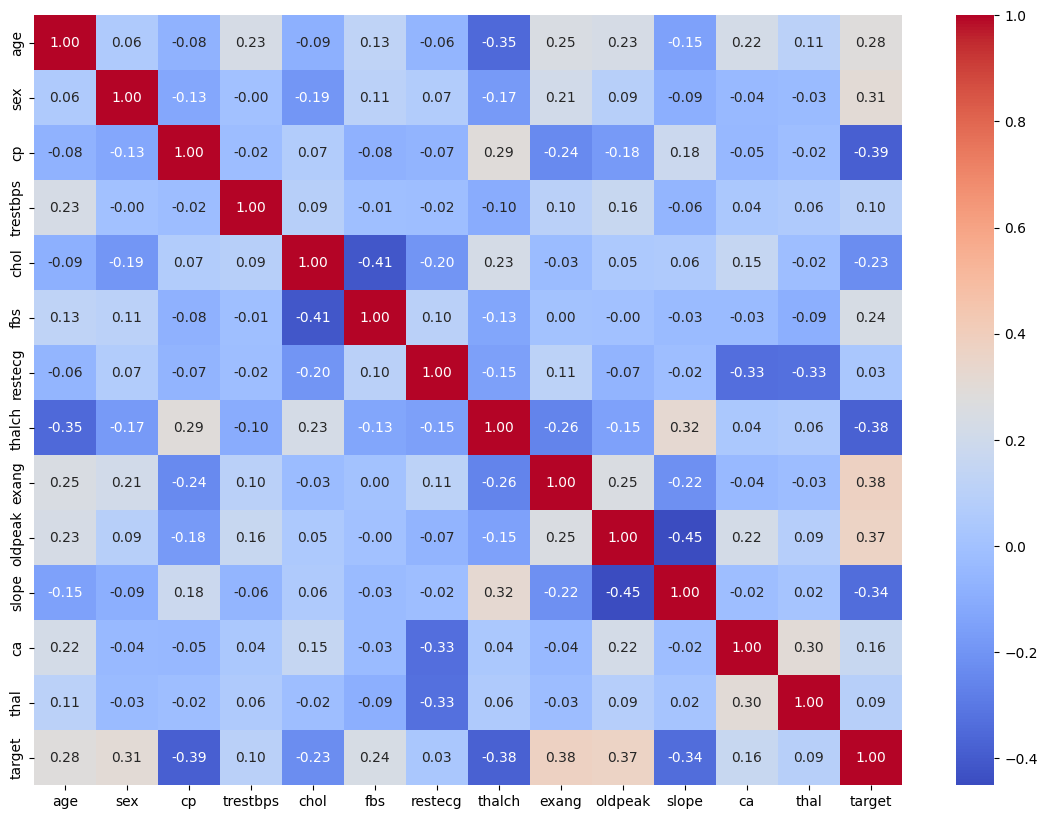

In [61]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [62]:
print(df.dtypes)

age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalch      float64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal          int64
target        int64
dtype: object


In [63]:
X = df.drop("target", axis=1)
y = df["target"]

In [64]:
print(X.shape)
print(y.shape)

(920, 13)
(920,)


In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [66]:
print(X_train.shape)
print(X_test.shape)

(736, 13)
(184, 13)


In [68]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [69]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [70]:
y_pred = lr.predict(X_test)

In [71]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8260869565217391


In [72]:
print("Precision:", precision_score(y_test, y_pred))

Precision: 0.8301886792452831


In [73]:
print("Recall:", recall_score(y_test, y_pred))

Recall: 0.8627450980392157


In [74]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.78      0.80        82
           1       0.83      0.86      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



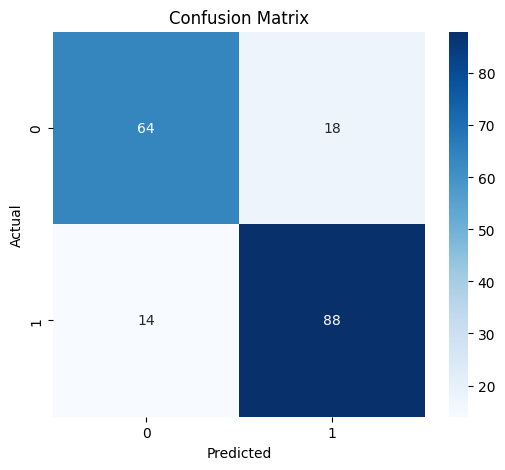

In [75]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

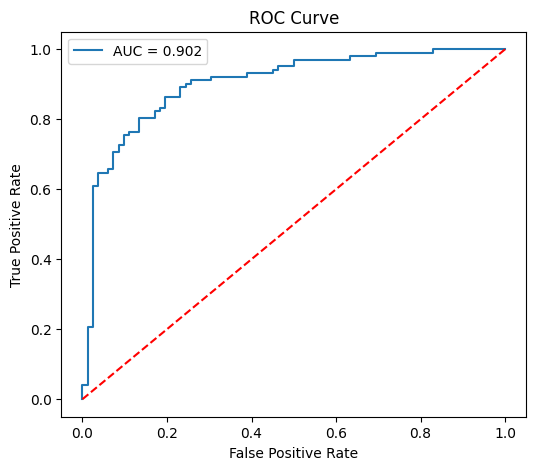

In [76]:
y_prob = lr.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [77]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [78]:
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))

Accuracy : 0.782608695652174
Precision: 0.7870370370370371
Recall   : 0.8333333333333334


In [79]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))

Accuracy : 0.8260869565217391
Precision: 0.8301886792452831
Recall   : 0.8627450980392157


In [80]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, dt_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, dt_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.826087,0.830189,0.862745
1,Decision Tree,0.782609,0.787037,0.833333


In [81]:
import pickle

pickle.dump(lr, open("heart_disease_model.pkl", "wb"))

pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [84]:
sample = X.iloc[[0]]


sample_scaled = scaler.transform(sample)


prediction = lr.predict(sample_scaled)

if prediction[0] == 1:
    print("Prediction: Heart Disease Detected")
else:
    print("Prediction: No Heart Disease")

Prediction: No Heart Disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
